In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
print("Hello ML")

Hello ML


In [2]:
housing_full = pd.read_csv(Path("datasets/housing/housing.csv"))

In [3]:
housing_full.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
housing_full.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [5]:
housing_full.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


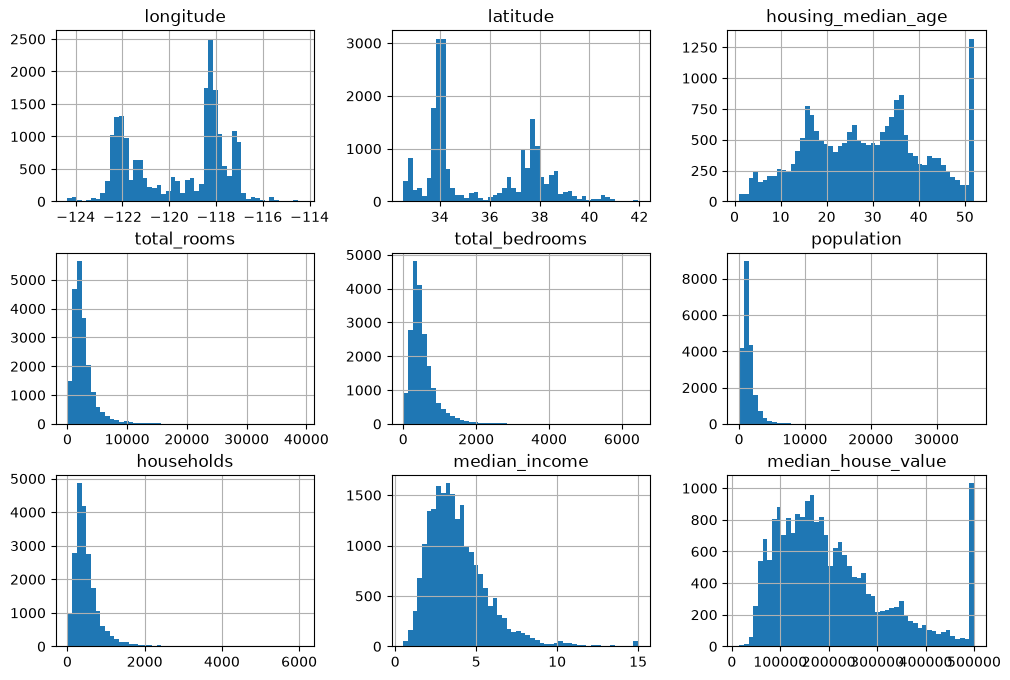

In [6]:
housing_full.hist(bins=50, figsize=(12, 8))
plt.show()

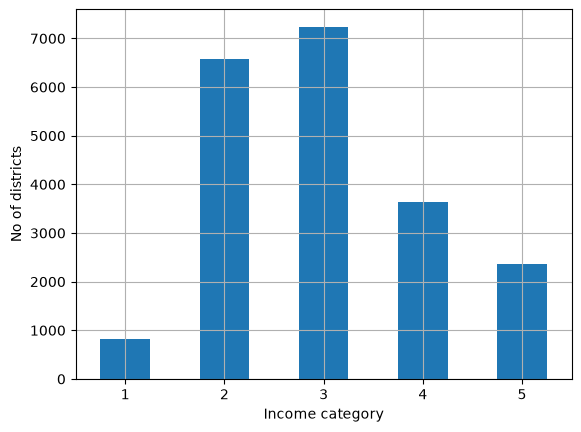

1316.2


In [7]:
housing_full["income_cat"] = pd.cut(housing_full["median_income"],
                                    bins=[0,1.5,3.0,4.5,6, np.inf],
                                    labels=[1,2,3,4,5])

cat_counts = housing_full['income_cat'].value_counts().sort_index()
cat_counts.plot.bar(rot=0, grid = True)
plt.xlabel("Income category")
plt.ylabel("No of districts")
plt.show()
print(cat_counts[2]*0.2)

In [8]:
#Random sampling into train and test set:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split( housing_full, test_size=0.2, random_state=42)

In [9]:
test_set["income_cat"].value_counts()

income_cat
3    1425
2    1269
4     760
5     499
1     175
Name: count, dtype: int64

In [10]:
#Stratified sampling into train and test set:
strat_train_set, strat_test_set = train_test_split( housing_full, test_size=0.2, random_state=42, stratify=housing_full["income_cat"])

In [11]:
strat_test_set["income_cat"].value_counts()

income_cat
3    1447
2    1316
4     728
5     472
1     165
Name: count, dtype: int64

Now after spliting we can delete income_cat column from splits cause it can make our model learn extra noise and overfit th data.

As we original data doesn't contain categories and we aren't using input data to find category and give it to model.

so drop the column

In [12]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

As in cell 16 we catogorized whole dataset and also printed no of districts of category 2 and in two different sampling and spliting methods random and stratified(median income) we got train set and test set.

So the value printed in cell 16 is 20% of no of districts belonging to 2nd category = 1316.2

And we extracted exact values of eac categories in test set derived from both ways(random and stratified(median income)).

We can see in random (2nd cat) = 1269
while in stratified (end cat) = 1316

So closer value to 1316.2 is in stratified sampling so its important to have train and test sets stratified means having similar data distribution/

Conclusion: we always you well distributed and stratified data to get good test instances which can train and validate our model in all aspects.

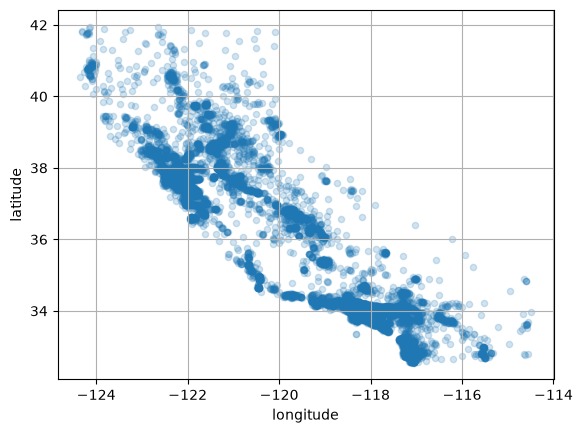

In [13]:
#Visualize geographical data. alpha helps to focus on denser regions.
housing = strat_train_set.copy()

housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=0.2)
plt.show()

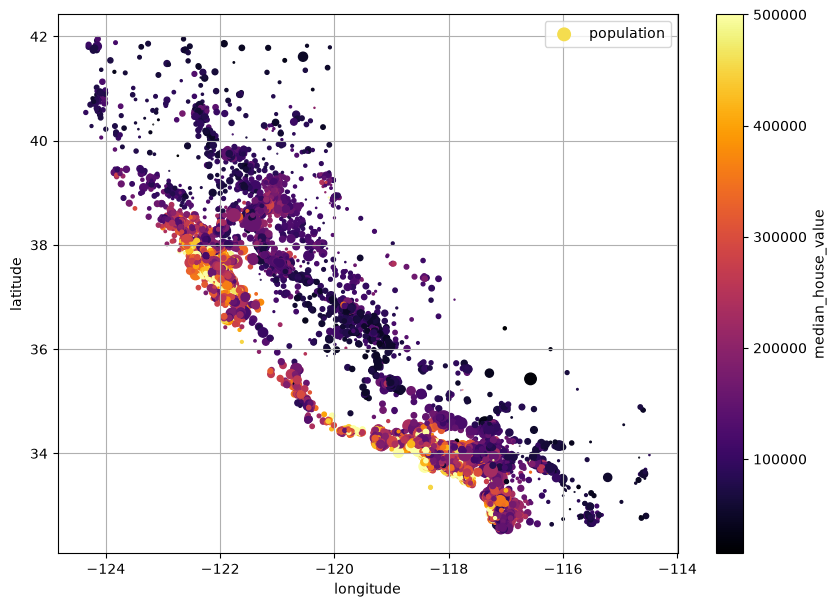

In [14]:
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True,
            s=housing["population"] / 100, label="population",
            c="median_house_value", cmap="inferno", colorbar=True,
            legend=True, sharex=False, figsize=(10,7))
plt.show()

We can see prime locations are BAY, costal and lowers regions, we can say that housing prices are dependent on location and population density. We need to find these patterns and Correlations.

In [15]:
corr_matrix = housing.corr(numeric_only=True)

corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
Name: median_house_value, dtype: float64

Found correlation coefficient (pearson's r) of each attribute with median house value, to get relation and it varies from -1 to 1. Closer to 1 means housing value increase as the respective atrribute increases. Closer to -1 means housing valuse decreases as the respective value increases.

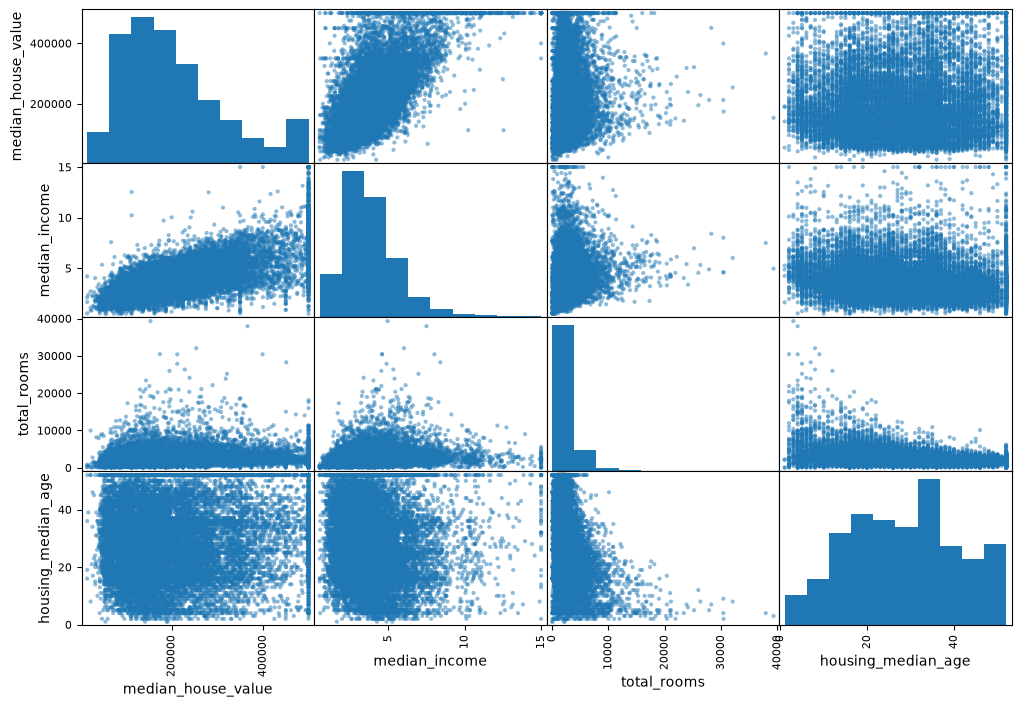

In [16]:
from pandas.plotting import scatter_matrix

attributes = ["median_house_value", "median_income", "total_rooms", "housing_median_age"]

scatter_matrix(housing[attributes], figsize=(12,8))
plt.show()

From Correlation coefficient and scattered plots of each attributes we found median income with highest positive coefficient and also it's graph shows linear relation as housing_values increase with increasing income.

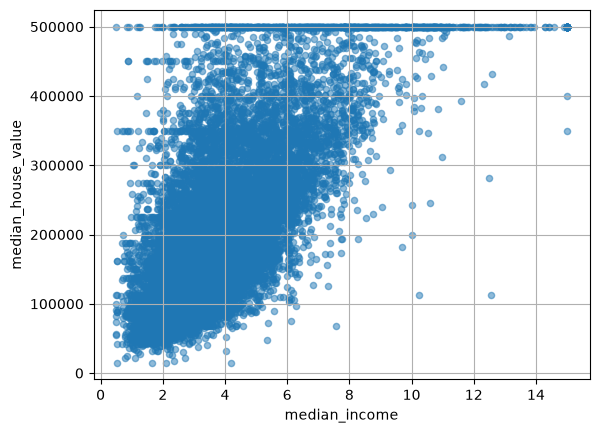

In [17]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.5, grid=True)
plt.show()

*We* will also look for some new attributes which can be created like rooms_per_house, bedroom_ratio ,bedrooms_per_house, people_per_house and compare their correlation factors.

In [18]:
housing["rooms_per_house"] = housing["total_rooms"] / housing["households"]
housing["bedroom_per_house"] = housing["total_bedrooms"] / housing["households"]
housing["bedroom_ratio"] = housing["total_bedrooms"] / housing["total_rooms"]
housing["people_per_house"] = housing["population"] / housing["households"]

new_corr_matrix = housing.corr(numeric_only=True)
new_corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
people_per_house     -0.038224
bedroom_per_house    -0.045545
longitude            -0.050859
latitude             -0.139584
bedroom_ratio        -0.256397
Name: median_house_value, dtype: float64

Rooms per house and bedroom ratio has good correlation factor than total rooms and bedrooms. These insights are helpfull.

In [19]:
#Now cleaning process starts to prepare data for ml aogorithms.

housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

#Seperated the labels and instances.

Data cleaning data usually means making data reliable and consumable by ml algorithms.
1. Handling missing values.
2. Removing Duplicates.
3. Fix Incorrect data.
4. Handle outliers.
5. Standardize formats like fonts, styles, upper/lowercase, making similar to avoid confusion.
6. Feature Engineering accumlating data two or more attributtes to make more reliable and effective attribute/s. Reduces data complexity and unwanted features.
7. Convert Categorical Data. ml needs numaerical data, so attributes are encoded into numbers or can be categotised.

In [20]:
# We need to handle the total_bedrooms missing value so we using imputation method(fil null values with median of the attribute).

median = housing_full["total_bedrooms"].median()
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(median)


In [21]:
# We can chek if any other null values present.
housing.info()
# Perfect no null values present.

<class 'pandas.DataFrame'>
Index: 16512 entries, 13096 to 19888
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           16512 non-null  float64
 1   latitude            16512 non-null  float64
 2   housing_median_age  16512 non-null  float64
 3   total_rooms         16512 non-null  float64
 4   total_bedrooms      16512 non-null  float64
 5   population          16512 non-null  float64
 6   households          16512 non-null  float64
 7   median_income       16512 non-null  float64
 8   ocean_proximity     16512 non-null  str    
dtypes: float64(8), str(1)
memory usage: 1.3 MB


The above is usefull but we need to apply it on all datasets to handle missing values. So instead we can ue SimpleImputer class from scikit learn and create a instance and use it to handle any dataset, any attribute.

In [22]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

In [23]:
#But we can only use it on numerical values so extract only num values from train_set

housing_num = housing.select_dtypes(include=np.number)

#No fit the imouter to the new traing data, it will fill statistic values of each attribute
imputer.fit(housing_num)

imputer.statistics_


array([-118.51  ,   34.26  ,   29.    , 2125.    ,  435.    , 1167.    ,
        408.    ,    3.5385])

In [24]:
# Now replace null with median of all attributes of each instance.

X = imputer.transform(housing_num)

#Sklearn outputs are always np.arrays so convert to pd.dataframes

housing_tr = pd.DataFrame(X, columns=housing_num.columns, index=housing_num.index)

Now we will handle text values/attributes cause ml mostly works on numbers so convert them to numbers. We similar attribute which is "ocean_proximity" it can be categorized as seen all instances have values among these: ['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN']

In [25]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head(10)

,ocean_proximity
13096,NEAR BAY
14973,<1H OCEAN
3785,INLAND
14689,INLAND
20507,NEAR OCEAN
1286,INLAND
18078,<1H OCEAN
4396,NEAR BAY
18031,<1H OCEAN
6753,<1H OCEAN


We can use OrdinalEncoder to number the categories and replace eaach category with respective number in dataset but these numbers can be manipulative to ml as it can learn unneccessary patterns/noise like 1+2 = 3 so adding two categories we get third. So to avoid overfitting we will use OneHotEncoder which will use binary numbers(0,1) the category of instance will be marked as 1 and rest as 0, samee for all instances.

In [26]:
from sklearn.preprocessing import OneHotEncoder

cat_encoder = OneHotEncoder()

housing_cat_1hot = cat_encoder.fit_transform(housing_cat)

#we get array of bits for each instance of size 5=no of total categories.

housing_cat_1hot.toarray()

array([[0., 0., 0., 1., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 0., 1.],
       [1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1.]], shape=(16512, 5))

In [27]:
#List of categories
cat_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [28]:
#We got a sparsed matrix but to maintain good readability we must have specifing columns and notations so a dataframe si best way:

cat_encoder.feature_names_in_ # Shows which attribute our encoder is working on

array(['ocean_proximity'], dtype=object)

In [29]:
columns = cat_encoder.get_feature_names_out() # Shows all category names
print(columns)

['ocean_proximity_<1H OCEAN' 'ocean_proximity_INLAND'
 'ocean_proximity_ISLAND' 'ocean_proximity_NEAR BAY'
 'ocean_proximity_NEAR OCEAN']


In [30]:
housing_cat_1hot_output = pd.DataFrame(housing_cat_1hot.toarray(), columns=columns, index=housing.index)
housing_cat_1hot_output.head(5)

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
13096,0.0,0.0,0.0,1.0,0.0
14973,1.0,0.0,0.0,0.0,0.0
3785,0.0,1.0,0.0,0.0,0.0
14689,0.0,1.0,0.0,0.0,0.0
20507,0.0,0.0,0.0,0.0,1.0


In [31]:
print(type(housing_num)) # Only numeric_values
print(type(housing)) # Training set without median_house_value_column and also some missing values
print(type(housing_tr)) # Training set without any missing values and median_house_value_column
print(type(housing_cat_1hot_output)) # Categories dataframe
print(type(housing_cat_1hot))# Categories sparse matrix

<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'pandas.DataFrame'>
<class 'scipy.sparse._csr.csr_matrix'>


Feature Scaling : We should scale our feature cause they vary a lot in units examole median income ranges 0-15 (tens unit) and total_rooms ranges 6-39320(ten thousand unit) so this unit difference manipulatyes our ml model as they prefer large units but median_income is more important than total_room fro predictions. So to solve this problem we scale all features to similar unit using two methods: min-max scaling and standardization.

In [32]:
from sklearn.preprocessing import StandardScaler

std_scaller = StandardScaler()

housing_num_std_scaled = std_scaller.fit_transform(housing_num)

df_housing_num_std_scaled = pd.DataFrame(housing_num_std_scaled, columns=housing_num.columns, index=housing_num.index)


In [33]:
housing_num.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292


In [34]:
df_housing_num_std_scaled.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
13096,-1.423037,1.013606,1.861119,0.311912,1.368151,0.137460,1.394812,-0.936491
14973,0.596394,-0.702103,0.907630,-0.308620,-0.435951,-0.693771,-0.373485,1.171942
3785,-1.203098,1.276119,0.351428,-0.712240,-0.760737,-0.788768,-0.775727,-0.759789
14689,1.231216,-0.884924,-0.919891,0.702262,0.742286,0.383175,0.731375,-0.850281
20507,0.711362,-0.875549,0.589800,0.790125,1.595738,0.444376,1.755263,-0.180365


Transformations: transformers are used to tranform an input data to get desired output data. They use parameters calculated by estimators.

For this example we found heavy tails in feature distribution, so to handel then we should make them equally distributed by using log, square root,etc.

So we will build a custom transformer for that.

In [35]:
#Custom Transformer for log
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp, feature_names_out="one-to-one")
log_pop = log_transformer.fit_transform(housing[["population"]])

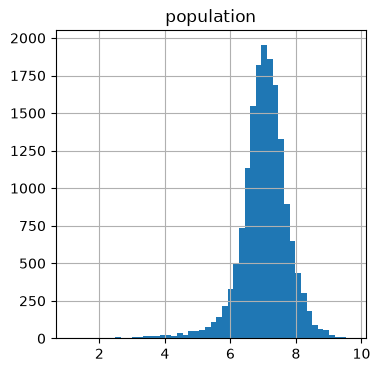

In [36]:
log_pop.hist(bins=50, figsize=(4,4))
plt.show()

We have usefull data that is location but it is in terms of longitude and latitude. But we have seen housing prices vary according to locality rather than exact co-ordinates. So giving just co-ordinates to model to predict prices will not be much eifficient so we will use k_means and rbf_kernal to identify each co-ordinates distance from clustered/important location from the data.

A city has some famous location which is highly populated. So houses near those regions will have more value than the far ones.
K_means helps in identifing those famous regions.
rbf_kernal helps in finding distance between each instance and the famous region, gives similarity score (0-1).

In [37]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.cluster import KMeans
from sklearn.base import BaseEstimator, TransformerMixin

class ClusterSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, X, y=None, sample_weight=None):
        self.kmeans_= KMeans(self.n_clusters, random_state=self.random_state)
        self.kmeans_.fit(X, sample_weight=sample_weight)
        return self
    
    def transform(self, X):
        return rbf_kernel(X, self.kmeans_.cluster_centers_, gamma=self.gamma)
    
    def get_feature_names_out(self, names=None):
        return [f"Cluster {i} similarity" for i in range(self.n_clusters)]

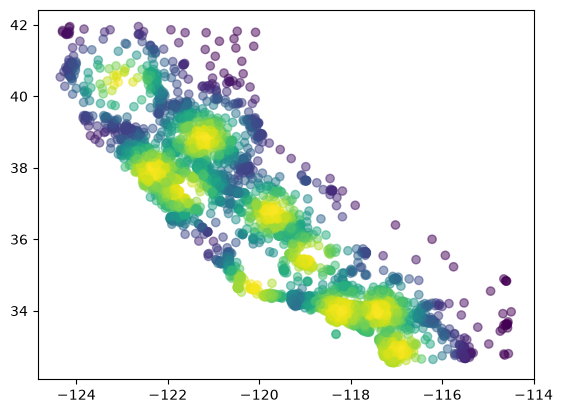

In [38]:
cluster_simil = ClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)
similarities = cluster_simil.fit_transform(housing[["latitude", "longitude"]])

longitude = housing[["longitude"]]
latitude = housing[["latitude"]]

plt.scatter(longitude, latitude, c=similarities.max(axis=1), alpha=0.5)
plt.show()

# Yellow highlighted regions are the clusters.

Now lets automate all tranformations using pipelines. Transformation pipelines are build to automate and maintaine the sequence of transformation, esimators used to transform data and provide it to next estimator.

In [39]:
# pipelines of numeric transformations and categorization of ocean_proximities.
from sklearn.pipeline import make_pipeline, Pipeline

num_pipeline = make_pipeline(SimpleImputer(strategy="median"), StandardScaler())

cat_pipeline = make_pipeline(SimpleImputer(strategy="most_frequent"), OneHotEncoder(handle_unknown="ignore"))

In [40]:
# Now for ratios

def column_ratio(X):
    return X[:, [0]] / X[:, [1]]

def ratio_name(function_transformer, feature_names_in):
    return ['ratio']

ratio_pipeline = make_pipeline(SimpleImputer(strategy="median"), FunctionTransformer(column_ratio, feature_names_out=ratio_name), StandardScaler())

In [41]:
#For log 
log_pipeline = make_pipeline(SimpleImputer(strategy="median"), log_transformer)

#Kmeans clusers and rbf similarity.
cluster_simil = ClusterSimilarity(n_clusters=45, gamma=1.0, random_state=42)

In [42]:
#Now we will automate all these under single tranformer:
from sklearn.compose import ColumnTransformer, make_column_selector

preprocessing = ColumnTransformer([
    ("bedrooms", ratio_pipeline, ['total_bedrooms', 'total_rooms']),
    ("rooms_per_house", ratio_pipeline, ['total_rooms', 'households']),
    ("people_per_house", ratio_pipeline, ['population', 'households']),
    ("log", log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ("geo", cluster_simil, ['latitude', 'longitude']),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
], remainder=num_pipeline)

housing_prepared = preprocessing.fit_transform(housing)
housing_prepared.shape

(16512, 59)

In [43]:
df_housing_prepared = pd.DataFrame(housing_prepared, columns=preprocessing.get_feature_names_out(), index=housing.index)
df_housing_prepared.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__total_bedrooms,log__total_rooms,log__population,log__households,log__median_income,geo__Cluster 0 similarity,geo__Cluster 1 similarity,...,geo__Cluster 41 similarity,geo__Cluster 42 similarity,geo__Cluster 43 similarity,geo__Cluster 44 similarity,cat__ocean_proximity_<1H OCEAN,cat__ocean_proximity_INLAND,cat__ocean_proximity_ISLAND,cat__ocean_proximity_NEAR BAY,cat__ocean_proximity_NEAR OCEAN,remainder__housing_median_age
13096,1.845250,-0.866027,-0.330204,7.016610,8.108021,7.362645,6.941190,0.741318,6.028456e-01,1.633902e-14,...,1.558800e-02,3.881481e-24,7.726746e-15,9.620597e-01,0.0,0.0,0.0,1.0,0.0,1.861119
14973,-0.507880,0.024550,-0.253616,5.869297,7.583248,6.501290,5.877736,1.806254,1.700117e-10,9.596010e-01,...,1.938346e-09,2.747606e-02,9.209123e-01,4.244715e-13,1.0,0.0,0.0,0.0,0.0,0.907630
3785,-0.202124,-0.041193,-0.051041,5.379897,6.987490,6.331502,5.313206,0.889125,3.103830e-01,4.937424e-15,...,8.016413e-02,8.916827e-25,3.242197e-15,7.173895e-01,0.0,1.0,0.0,0.0,0.0,0.351428
14689,-0.149011,-0.034858,-0.141475,6.746412,8.336630,7.520235,6.659294,0.816161,3.010607e-16,2.302017e-01,...,8.538234e-14,3.686262e-01,3.368282e-01,2.312643e-19,0.0,1.0,0.0,0.0,0.0,-0.919891
20507,0.962439,-0.666554,-0.306148,7.099202,8.381603,7.555905,7.066467,1.261071,2.684693e-12,9.446799e-01,...,3.284173e-11,1.149964e-01,9.047234e-01,3.871626e-15,0.0,0.0,0.0,0.0,1.0,0.589800


We have prepared our final training set that can be provided to ml model to perform efficiently than raw data.

Now lets select most suitable model to train.

In [44]:
# We will use simple linear model (linear regression)

from sklearn.linear_model import LinearRegression

lin_reg = make_pipeline(preprocessing, LinearRegression())
lin_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [45]:
#Lets check predictions for training set and compare with labels.

housing_predictions = lin_reg.predict(housing)
housing_predictions[:5].round(-2)

array([276000., 373200., 106400., 126700., 279200.])

In [46]:
housing_labels.iloc[:5].values

array([458300., 483800., 101700.,  96100., 361800.])

We can see our first two predictions are way too off but next ones are some what closer to labels. Lets find RMSE value.

In [47]:
from sklearn.metrics import root_mean_squared_error

lin_rmse = root_mean_squared_error(housing_labels, housing_predictions)
lin_rmse

63670.27680664377

This is not a good score each district values are differed by an avg of $68975 which is a huge difference. As we can see our model is performing poor itself in training set so this is an example of underfitting. Wethers it got less info to predict(less parameters, features) or we choose very simple model to predict. Before increasing features we will try more powerfull model.

In [48]:
# Model training
from sklearn.tree import DecisionTreeRegressor

dis_reg = make_pipeline(preprocessing, DecisionTreeRegressor(random_state=42))
dis_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto

In [49]:
# Train_set predictions
housing_predictions_dis = dis_reg.predict(housing)
housing_predictions_dis[:5].round(-2)

array([458300., 483800., 101700.,  96100., 361800.])

In [50]:
# Train_set rsme
dis_rmse = root_mean_squared_error(housing_labels, housing_predictions_dis)
dis_rmse

0.0

We got the model with perfect predictions on training set. So features/ limited info wasn't the problem, it was simple model usage as decisiontreeregressor is more pwerfull than linearegressor so it learn't all features and made good predictions. But this doesn't mean its over now just deploy and use model, we have to check wether the model is not overfitted and that can be done using test_set lets analyse performance of the model on test_set. 

In [51]:
test_housing = strat_test_set.drop("median_house_value", axis=1)
test_housing_labels = strat_test_set["median_house_value"].copy()

In [52]:
# Test_set predictions
test_housing_predictions_dis = dis_reg.predict(test_housing)
test_housing_predictions_dis[:5].round(-2)

array([402300., 188400., 432500., 315200., 275000.])

In [53]:
test_housing_labels.iloc[:5].values

array([397700., 202900., 310000., 314300., 187500.])

In [54]:
# Test_set rsme
test_rsme = root_mean_squared_error(test_housing_labels, test_housing_predictions_dis)
test_rsme

63057.84322997331

We can see it our model performed poor on test_set and got rsme around $106022 which is a lot huge difference. So this is an example of overfitting.
What we can do to solve is lower some features, use less complex model or we can tune hyperparameters by using hold_out_validation technique.

We can do cross_validation without evaluating test_set.

It evaluated using K-splits of train_set
Trained on k-1 splits and evaluated with the remaining split
Such operation is run K times to get the scores.

In [55]:
from sklearn.model_selection import cross_val_score

dis_rsme = -cross_val_score(dis_reg, housing, housing_labels, scoring= "neg_root_mean_squared_error", cv=10)#applied (-) to convert score to positive

pd.Series(dis_rsme).describe()

count       10.000000
mean     64120.309376
std       2147.948217
min      61527.064880
25%      62360.550361
50%      64088.976514
75%      65634.456923
max      68075.893846
dtype: float64

Now we can choose a best model but all have same rsme and also they are performing same as linearregressor model so no benefit in using decisiontreeregressor model. We can use RandomForestRegressor and see how it performs.

In [56]:
from sklearn.ensemble import RandomForestRegressor

forest_reg = make_pipeline(preprocessing, RandomForestRegressor(random_state=42))
forest_reg.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('randomforestregressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto

In [57]:
forest_housing_predictions = forest_reg.predict(housing)
forest_housing_predictions[:5].round(-2)

array([424300., 464200., 109700., 101700., 366400.])

In [58]:
forest_rsme = root_mean_squared_error(housing_labels, forest_housing_predictions)
forest_rsme

16780.971987212502

We got a decent and lower rsme value compared to linear regression now lets check cross-validation

In [59]:
forest_rsme = -cross_val_score(forest_reg, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10) #Trains 10 times.
pd.Series(forest_rsme).describe()

count       10.000000
mean     45137.276304
std        915.691408
min      44152.988406
25%      44381.837303
50%      45267.525011
75%      45314.702177
max      47273.936759
dtype: float64

We got much better stats than decisiontreeregressor model. We can see rsme on training set is much lower so it is quite still overfitting going on.

So without just wasting time in tweaking the hyperparameters, we got few models lets fine tune them.

For fine tuning we using Grid Search. It takes hyperparameters and test them in cross validation and gives best out of the options.

In [60]:
from sklearn.model_selection import GridSearchCV

full_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("random_forest", RandomForestRegressor(random_state=42))
])

param_grid = [
    {
        'preprocessing__geo__n_clusters':[5,8,10],
        'random_forest__max_features':[4,6,8]
    },
    {
        'preprocessing__geo__n_clusters':[10,15],
        'random_forest__max_features':[6,8,10]
    }
]

grid_search = GridSearchCV(full_pipeline, param_grid=param_grid, cv=3, scoring="neg_root_mean_squared_error")

grid_search.fit(housing, housing_labels) # Trains 45 times.

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","[{'preprocessing__geo__n_clusters': [5, 8, ...], 'random_forest__max_features': [4, 6, ...]}, {'preprocessing__geo__n_clusters': [10, 15], 'random_forest__max_features': [6, 8, ...]}]"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cr

In [61]:
# Finidng best hyperparameters.
grid_search.best_params_

{'preprocessing__geo__n_clusters': 15, 'random_forest__max_features': 6}

In [62]:
# We got the new estimator which uses 29 features instead of just 24 which were our provided. % new features got added and they contribute in 
#predictions. This new 5 features are due to our n_clusters chenged to 15 as it is best prama.

grid_search.best_estimator_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will 

In [63]:
cv_rsme = pd.DataFrame(grid_search.cv_results_)
cv_rsme.sort_values(by="mean_test_score", ascending=False, inplace=True)
cv_rsme.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
12,7.309294,0.209113,0.267090,0.004357,15,6,"{'preprocessing__geo__n_clusters': 15, 'random...",-43520.768457,-43946.953915,-44749.079200,-44072.267191,509.224498,1
13,8.971488,0.341762,0.249362,0.011061,15,8,"{'preprocessing__geo__n_clusters': 15, 'random...",-44027.292633,-44210.486453,-45037.515120,-44425.098069,439.454948,2
14,10.419311,0.087969,0.240731,0.016606,15,10,"{'preprocessing__geo__n_clusters': 15, 'random...",-44401.644244,-44537.046324,-45472.278275,-44803.656281,476.007674,3
7,5.246312,0.293262,0.193931,0.033216,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44251.229681,-44826.790667,-45575.333051,-44884.451133,542.098380,4
9,4.901038,0.094437,0.188782,0.028215,10,6,"{'preprocessing__geo__n_clusters': 10, 'random...",-44251.229681,-44826.790667,-45575.333051,-44884.451133,542.098380,4


We used gridsearch to find best_param but it evaluated only the list of param we gave and fount best out of them so it is irritating to think and give params so instead we can use randomserach which just needs range of params and evaluates them all and dosn't need to train millions of times like gridsearch.

In [64]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

param_distribution = {
        'preprocessing__geo__n_clusters': randint(low=3, high=50),
        'random_forest__max_features':randint(low=2, high=20)
    }

rnd_search = RandomizedSearchCV(
    full_pipeline, param_distributions=param_distribution, n_iter=10, cv=3, scoring="neg_root_mean_squared_error", random_state=42
    )

rnd_search.fit(housing, housing_labels)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'preprocessing__geo__n_clusters': <scipy.stats....00202730E1A90>, 'random_forest__max_features': <scipy.stats....002026F925E50>}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchC

In [65]:
rnd_search.best_params_

{'preprocessing__geo__n_clusters': 45, 'random_forest__max_features': 9}

In [66]:
rnd_results = pd.DataFrame(rnd_search.cv_results_)
rnd_results.sort_values(by="mean_test_score", ascending=False, inplace=True)
rnd_results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_preprocessing__geo__n_clusters,param_random_forest__max_features,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
1,10.427306,0.242782,0.275840,0.023033,45,9,"{'preprocessing__geo__n_clusters': 45, 'random...",-41204.006528,-42132.070337,-42840.094407,-42058.723757,669.940633,1
8,7.077977,1.423643,0.235528,0.057654,32,7,"{'preprocessing__geo__n_clusters': 32, 'random...",-41991.453792,-42544.884528,-43311.971826,-42616.103382,541.446251,2
5,5.067850,0.216317,0.277055,0.018570,42,4,"{'preprocessing__geo__n_clusters': 42, 'random...",-42030.576161,-43036.458311,-43589.216657,-42885.417043,645.213219,3
0,16.660690,0.070157,0.242059,0.002129,41,16,"{'preprocessing__geo__n_clusters': 41, 'random...",-42580.486638,-42870.275180,-43470.134894,-42973.632237,370.477634,4
2,8.863220,0.379803,0.242485,0.027301,23,8,"{'preprocessing__geo__n_clusters': 23, 'random...",-42421.457319,-42880.830573,-44294.330282,-43198.872725,796.984479,5


In [67]:
final_model = rnd_search.best_estimator_

feature_imp=final_model["random_forest"].feature_importances_

In [68]:
perfect_model_predictions = final_model.predict(housing)
perfect_model_rsme = root_mean_squared_error(housing_labels, perfect_model_predictions)
perfect_model_rsme

15219.543258754846

In [69]:
feature_imp.round(2)

array([0.06, 0.06, 0.05, 0.01, 0.01, 0.01, 0.01, 0.19, 0.01, 0.02, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.02, 0.01, 0.  , 0.01, 0.01,
       0.01, 0.  , 0.01, 0.  , 0.02, 0.01, 0.01, 0.  , 0.01, 0.01, 0.01,
       0.02, 0.02, 0.01, 0.01, 0.01, 0.04, 0.01, 0.02, 0.01, 0.01, 0.01,
       0.02, 0.01, 0.  , 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.  , 0.08,
       0.  , 0.  , 0.  , 0.01])

we found out impotance of each feature in predicting housing_value. We will use SelectFromModel to analyse importance and remove least important features to see some improvements.

In [70]:
from sklearn.feature_selection import SelectFromModel

selectfrommodel = SelectFromModel(final_model["random_forest"], prefit=True)

reduced_housing = selectfrommodel.transform(housing_prepared)

In [71]:
# For selected features.
feature_names = preprocessing.get_feature_names_out()
selected_features = feature_names[selectfrommodel.get_support()]
print(len(selected_features))
print(selected_features)

12
['bedrooms__ratio' 'rooms_per_house__ratio' 'people_per_house__ratio'
 'log__median_income' 'geo__Cluster 3 similarity'
 'geo__Cluster 9 similarity' 'geo__Cluster 18 similarity'
 'geo__Cluster 25 similarity' 'geo__Cluster 30 similarity'
 'geo__Cluster 32 similarity' 'geo__Cluster 36 similarity'
 'cat__ocean_proximity_INLAND']


These above are the important and high importance scored features which will contribute a lot in predictions than others. Now we have reduced_housing we will use it as our final training set to train a new model and check for results(rsme score)

In [72]:
reduced_housing.shape

reduced_housing_df = pd.DataFrame(reduced_housing, columns=selected_features, index=housing.index)

reduced_housing_df.head()

,bedrooms__ratio,rooms_per_house__ratio,people_per_house__ratio,log__median_income,geo__Cluster 3 similarity,geo__Cluster 9 similarity,geo__Cluster 18 similarity,geo__Cluster 25 similarity,geo__Cluster 30 similarity,geo__Cluster 32 similarity,geo__Cluster 36 similarity,cat__ocean_proximity_INLAND
13096,1.845250,-0.866027,-0.330204,0.741318,8.478679e-07,3.744461e-04,1.961468e-04,8.235405e-04,1.005731e-06,0.000024,4.189603e-11,0.0
14973,-0.507880,0.024550,-0.253616,1.806254,1.258757e-02,1.107138e-04,8.725171e-04,1.171753e-12,1.291404e-05,0.002058,6.188390e-01,0.0
3785,-0.202124,-0.041193,-0.051041,0.889125,1.446130e-06,7.488616e-04,3.865400e-05,1.641748e-02,1.097851e-05,0.000038,9.015865e-12,1.0
14689,-0.149011,-0.034858,-0.141475,0.816161,7.737234e-05,6.548659e-08,1.522829e-07,5.458362e-17,6.935851e-08,0.000004,1.714459e-02,1.0
20507,0.962439,-0.666554,-0.306148,1.261071,1.753022e-03,6.644262e-06,9.492050e-05,1.128317e-14,7.732975e-07,0.000197,3.456311e-01,0.0


In [73]:
#Now train an new model with this reduced/only important featured training set.
best_rf = final_model["random_forest"]

new_model = Pipeline([
    ("preprocessing", preprocessing),
    ("feature_reducer", selectfrommodel),
    ("random_forest", RandomForestRegressor(
    n_estimators=best_rf.n_estimators,
    max_features=best_rf.max_features,
    max_depth=best_rf.max_depth,
    min_samples_leaf=best_rf.min_samples_leaf,
    min_samples_split=best_rf.min_samples_split,
    random_state=42
))
])
new_model.fit(housing, housing_labels)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature_reducer', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['longitude','latitude','housing_median_age',...,'households', 'median_income','ocean_proximity']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('bedrooms', ...), ('rooms_per_house', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit

In [74]:
new_model_predictions = new_model.predict(housing)
new_model_predictions[:5].round(-2)

array([420000., 467000., 110100.,  99400., 348100.])

In [75]:
new_model_rsme = root_mean_squared_error(housing_labels, new_model_predictions)
new_model_rsme

17582.916173272988

In [77]:
new_model_rsme = -cross_val_score(new_model, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10) #Trains 10 times.
pd.Series(new_model_rsme).describe()

ValueError: 
All the 10 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "d:\coding\realestatecompany\.venv\Lib\site-packages\sklearn\feature_selection\_from_model.py", line 370, in fit
    check_is_fitted(self.estimator)
    ~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^
  File "d:\coding\realestatecompany\.venv\Lib\site-packages\sklearn\utils\validation.py", line 1718, in check_is_fitted
    raise NotFittedError(msg % {"name": type(estimator).__name__})
sklearn.exceptions.NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  Fil

In [ ]:
pd.Series(new_model_rsme).head()

In [79]:
final_model_rsme = -cross_val_score(final_model, housing, housing_labels, scoring="neg_root_mean_squared_error", cv=10) #Trains 10 times.
pd.Series(final_model_rsme).describe()

count       10.000000
mean     41136.727158
std       1275.216024
min      38688.198001
25%      40571.583260
50%      41144.854579
75%      41667.778564
max      43165.486538
dtype: float64

In [ ]:
test_predictions = final_model.predict(test_housing)

test_predictions_rsme = root_mean_squared_error(test_housing_labels, test_predictions)
test_predictions_rsme

In [ ]:
test_new_model_predictions = new_model.predict(test_housing)
test_new_model_predictions_rsme = root_mean_squared_error(test_housing_labels, test_new_model_predictions)
test_new_model_predictions_rsme

Now we will build and use a Kneighbors custom transformer for countering outliers, smoothing median_income around the nearest instances.

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

class IncomeSmoother(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
    
    def fit(self, X=["longitude", "latitude"], Y="median_income"):
        self.knn = KNeighborsRegressor(n_neighbors=self.n_neighbors)
        self.knn.fit(X, Y)
        return self
    
    def transform(self, X):
        smooths=self.knn.predict(X)
        return np.array(smooths).reshape(-1, 1)

In [ ]:
Median_Income_Smother = IncomeSmoother(n_neighbors=5)
Median_Income_Smother.fit(housing[["longitude", "latitude"]], housing["median_income"])

In [ ]:
polished_median_income = Median_Income_Smother.transform(housing[["longitude", "latitude"]])

In [ ]:
preprocessing2 = ColumnTransformer([
    ("bedrooms", ratio_pipeline, ['total_bedrooms', 'total_rooms']),
    ("rooms_per_house", ratio_pipeline, ['total_rooms', 'households']),
    ("people_per_house", ratio_pipeline, ['population', 'households']),
    ("polished_median_income",Median_Income_Smother, ["median_income"]),
    ("log", log_pipeline, ['total_bedrooms', 'total_rooms', 'population', 'households', 'median_income']),
    ("geo", cluster_simil, ['latitude', 'longitude']),
    ("cat", cat_pipeline, make_column_selector(dtype_include=object))
], remainder=num_pipeline)

In [ ]:
forest_reg = make_pipeline(preprocessing2, RandomForestRegressor(random_state=42))
forest_reg.fit(housing, housing_labels)

In [ ]:
forest_reg_predictions = forest_reg.predict(housing)
forest_reg_rsme = root_mean_squared_error(housing_labels, forest_reg_predictions)
forest_reg_rsme

In [ ]:
test_forest_reg_predictions = forest_reg.predict(test_housing)
test_forest_reg_rsme = root_mean_squared_error(test_housing_labels, test_forest_reg_predictions)
test_forest_reg_rsme

In [80]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, loguniform

In [81]:
from sklearn.svm import SVR
from scipy.stats import loguniform


svr_pipeline = Pipeline([
    ("preprocessing", preprocessing),
    ("svr", SVR())
])

svr_param_distribution = {
    "svr__kernel": ["linear", "rbf"],
    "svr__C": loguniform(1, 100),
    "svr__gamma": loguniform(1, 20)
}

svr_reg = RandomizedSearchCV(
    svr_pipeline, svr_param_distribution, n_iter=10, cv=3, scoring="neg_root_mean_squared_error", random_state=42, n_jobs=-1
)

svr_reg.fit(housing.iloc[:5000], housing_labels.iloc[:5000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....0020256911010>, 'svr__gamma': <scipy.stats....0020230F74050>, 'svr__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` ins

In [82]:
svr_reg.best_params_

{'svr__C': np.float64(5.6115164153345045),
 'svr__gamma': np.float64(17.25471657328035),
 'svr__kernel': 'linear'}

In [83]:
svr_model = svr_reg.best_estimator_

In [84]:
svr_predictions = svr_model.predict(housing.iloc[:5000])

In [85]:
from sklearn.metrics import root_mean_squared_error

In [86]:
svr_rsme = root_mean_squared_error(housing_labels.iloc[:5000], svr_predictions)
svr_rsme

111354.80559514822

In [87]:
from sklearn.model_selection import cross_val_score

svr_cross_rmse = -cross_val_score(svr_model, housing.iloc[:5000], housing_labels.iloc[:5000], scoring="neg_root_mean_squared_error", cv=3)
pd.Series(svr_cross_rmse).describe()

count         3.000000
mean     113745.934314
std        2963.285768
min      110490.673927
25%      112475.631976
50%      114460.590026
75%      115373.564507
max      116286.538989
dtype: float64

In [88]:
svr_reg.fit(housing.iloc[:10000], housing_labels.iloc[:10000])

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...svr', SVR())])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'svr__C': <scipy.stats....0020256911010>, 'svr__gamma': <scipy.stats....0020230F74050>, 'svr__kernel': ['linear', 'rbf']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` ins

In [89]:
svr_reg.best_params_

{'svr__C': np.float64(5.6115164153345045),
 'svr__gamma': np.float64(17.25471657328035),
 'svr__kernel': 'linear'}

In [90]:
big_svr_model = svr_reg.best_estimator_

In [ ]:
big_svr_predictions = big_svr_model.predict(housing.iloc[:10000])

In [ ]:
big_svr_model_rmse = root_mean_squared_error(housing_labels.iloc[:10000], big_svr_predictions)
big_svr_model_rmse

In [ ]:
big_svr_cross_rmse = -cross_val_score(big_svr_model, housing.iloc[:10000], housing_labels.iloc[:10000], scoring="neg_root_mean_squared_error", cv=3)
pd.Series(big_svr_cross_rmse).describe()